**Step 1 — Verify GPU**

In [1]:
!nvidia-smi

Wed Aug 26 04:56:45 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

**Step 2 — Install required libraries**

In [2]:
!pip install -q diffusers transformers accelerate

**Step 3 — Load the Stable Diffusion model**

In [1]:
from diffusers import StableDiffusionPipeline
import torch

model_id = "runwayml/stable-diffusion-v1-5"

pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16
)
pipe = pipe.to("cuda")

print("Model loaded successfully!")

Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Model loaded successfully!


**Step 4 — Generate your first image**

  0%|          | 0/30 [00:00<?, ?it/s]

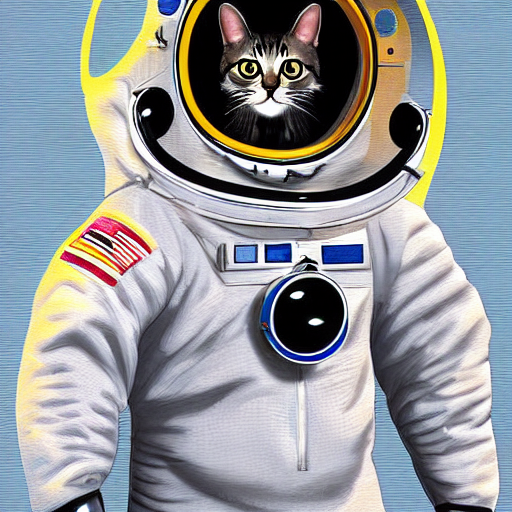

In [2]:
prompt = "a cat wearing a spacesuit, digital art, highly detailed"

image = pipe(prompt, num_inference_steps=30, guidance_scale=7.5).images[0]

image.save("generated_image.png")
image

  0%|          | 0/30 [00:00<?, ?it/s]

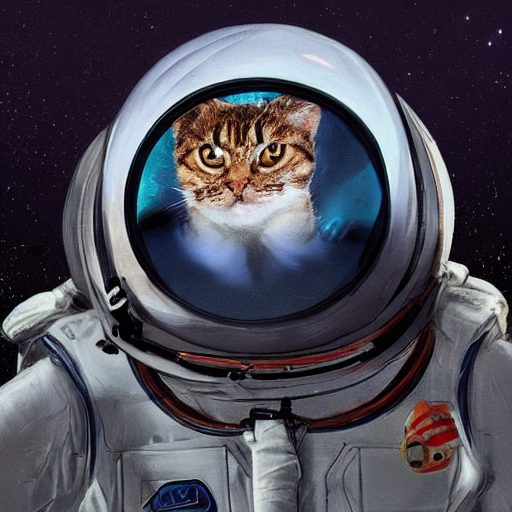

In [3]:
prompt = "a cat wearing a spacesuit, digital art, highly detailed"

image_low_guidance = pipe(prompt, num_inference_steps=30, guidance_scale=3).images[0]
image_low_guidance.save("low_guidance.png")
image_low_guidance